# Experiment  

The goal is to create a Hybrid Generative Adversarial Network-Assisted Monte Carlo (HG-MC), where the GAN is of the LSGAN variety, to improve the accuracy of options pricing vis-à-vis pure Monte Carlo — Which (pure Monte Carlo) uses a $X \sim \mathcal{N}(\mu=0,\ \sigma=1)$ distribution to model shocks. Here, we replace this with synthetically generated residuals of returns $Z_t = \frac{r_t - \left(\mu - \frac{1}{2}\sigma^2\right)\Delta t}{\sigma\sqrt{\Delta t}}$.  

An LSGAN is trained on 249 days of historical data of $Z_t$ of Nvidia stock closing price from the dates of May 10 2023 to May 7 2024. The LSGAN generates 60 days (observations) of $Z_t$ per simulation for 1000 simulations to price a hypothetical European call of expiration August 2 2024 and strike price $90. The out-of-sample Nvidia stock price at expiration is $107.27  

In practice, allowing the GAN to run train without restriction degrades performance, thus we anchor the mean of its generation to be the same as that of the historical unscaled mean of $Z_t$, despite training the LSGAN on scaled $Z_t$. Multiple reruns show that pricing is consistently better than pure MC and that this is not purely coincidental. 

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

In [2]:
df = pd.read_csv(r"C:\Users\User\Downloads\Nvidia Price.csv")
df1 = df.copy()

# Reverse order b/c original data is most recent date 1st 
df1 = df1.iloc[::-1].reset_index(drop=True)

# Remoce $ from  Close/Last column
df1["Close/Last"] = (
    df1["Close/Last"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .astype(float)
)
initial_price = df1["Close/Last"].iloc[-1]


# Returns
df1["returns"] = df1["Close/Last"].pct_change()
df1 = df1.dropna(subset=["returns"])


# Annualized parameters
mu = df1['returns'].mean() * 250
sigma = df1['returns'].std() * np.sqrt(250)

# Daily timestep
dt = 1 / 250

# Calculate standardized shocks Z_t
df1['Z_t'] = (
    df1['returns']
    - (mu - 0.5 * sigma**2) * dt
) / (sigma * np.sqrt(dt))

# This will anchor data generation
mean_of_Z_t = df1['Z_t'].mean()

# Model Definitions

In [8]:
# Data scaling and tensor conversion
scaler = StandardScaler()
scaled_Z_t = scaler.fit_transform(df1['Z_t'].values.reshape(-1, 1))
Z_t_tensor = torch.tensor(scaled_Z_t, dtype=torch.float32)

# Hyperparameters
p = 1
lr = 0.001
batch_size = 64
epochs = 1000

dataset = TensorDataset(Z_t_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


# Model architecture 
class Generator(nn.Module):
    def __init__(self, p):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(p, 8),
            nn.LeakyReLU(0.2),
            nn.Linear(8, 8),
            nn.LeakyReLU(0.2),
            nn.Linear(8, p)
        )

        # Define your strict target mean
        self.target_mean = mean_of_Z_t

    def forward(self, latent, rp):
        h = latent * rp
        fake_data = self.model(h)

        # Calculate the current batch mean
        current_mean = torch.mean(fake_data, dim=0, keepdim=True)

        # Shift the data so the batch mean is exactly the target_mean
        enforced_fake_data = fake_data - current_mean + self.target_mean

        return enforced_fake_data


class Discriminator(nn.Module):
    def __init__(self, p):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(p, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 1)   # No Sigmoid here, which is required for LSGAN
        )

    def forward(self, x):
        return self.model(x)


# Initialization
netG = Generator(p)
netD = Discriminator(p)

# --- CRITICAL CHANGE FOR LSGAN ---
# Replace BCEWithLogitsLoss with MSELoss
criterion = nn.MSELoss()

optimizerD = optim.Adam(netD.parameters(), lr=lr)
optimizerG = optim.Adam(netG.parameters(), lr=lr)


# Training Loop

Epoch [0/1000] | D Loss: 0.8360 | G Loss: 0.8065
Epoch [100/1000] | D Loss: 0.2502 | G Loss: 0.1305
Epoch [200/1000] | D Loss: 0.2434 | G Loss: 0.1288
Epoch [300/1000] | D Loss: 0.2422 | G Loss: 0.1295
Epoch [400/1000] | D Loss: 0.2435 | G Loss: 0.1296
Epoch [500/1000] | D Loss: 0.2529 | G Loss: 0.1253
Epoch [600/1000] | D Loss: 0.2506 | G Loss: 0.1269
Epoch [700/1000] | D Loss: 0.2448 | G Loss: 0.1300
Epoch [800/1000] | D Loss: 0.2446 | G Loss: 0.1284
Epoch [900/1000] | D Loss: 0.2449 | G Loss: 0.1305


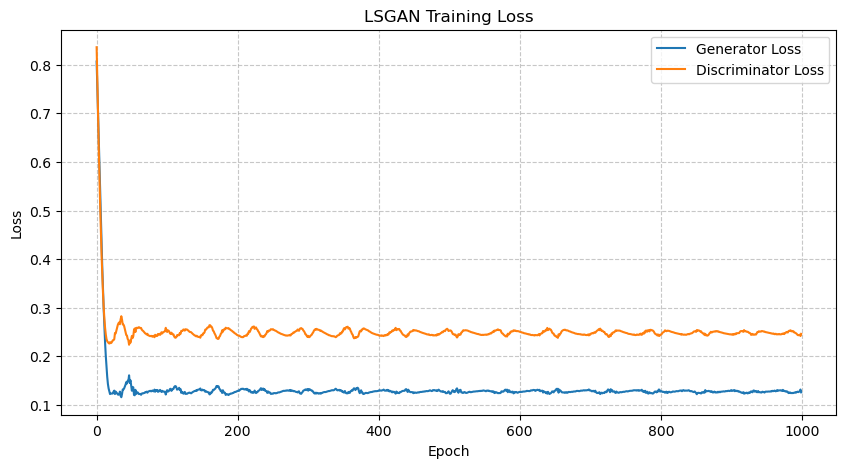

In [ ]:
g_losses = []
d_losses = []

for epoch in range(epochs):
    epoch_g_loss = 0
    epoch_d_loss = 0
    
    for i, (real_data,) in enumerate(dataloader):
        b_size = real_data.size(0)
        
        # 1. Train Discriminator
        netD.zero_grad()
        
        # Real data (target = 1.0)
        labels_real = torch.full((b_size, 1), 1.0)
        output_real = netD(real_data)
        lossD_real = criterion(output_real, labels_real)
        
        # Fake data (target = 0.0)
        latent = torch.randn(b_size, p)
        rp = torch.ones(b_size, 1)
        fake_data = netG(latent, rp)
        labels_fake = torch.full((b_size, 1), 0.0)
        output_fake = netD(fake_data.detach())
        lossD_fake = criterion(output_fake, labels_fake)
        
        # Combined LSGAN Discriminator Loss
        lossD = 0.5 * (lossD_real + lossD_fake) # LSGAN often uses 0.5 multiplier for stability
        lossD.backward()
        optimizerD.step()

        # Train Generator
        netG.zero_grad()
        # Generator wants Discriminator to output 1.0 for fake data
        labels_g = torch.ones(b_size, 1) 
        output_g = netD(fake_data)
        lossG = 0.5 * criterion(output_g, labels_g)
        lossG.backward()
        optimizerG.step()
        
        epoch_g_loss += lossG.item()
        epoch_d_loss += lossD.item()

    # Save average loss for the epoch
    g_losses.append(epoch_g_loss / len(dataloader))
    d_losses.append(epoch_d_loss / len(dataloader))

    if epoch % 100 == 0:
        print(f"Epoch [{epoch}/{epochs}] | D Loss: {d_losses[-1]:.4f} | G Loss: {g_losses[-1]:.4f}")


plt.figure(figsize=(10, 5))
plt.plot(g_losses, label="Generator Loss", color='tab:blue')
plt.plot(d_losses, label="Discriminator Loss", color='tab:orange')
plt.title("LSGAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

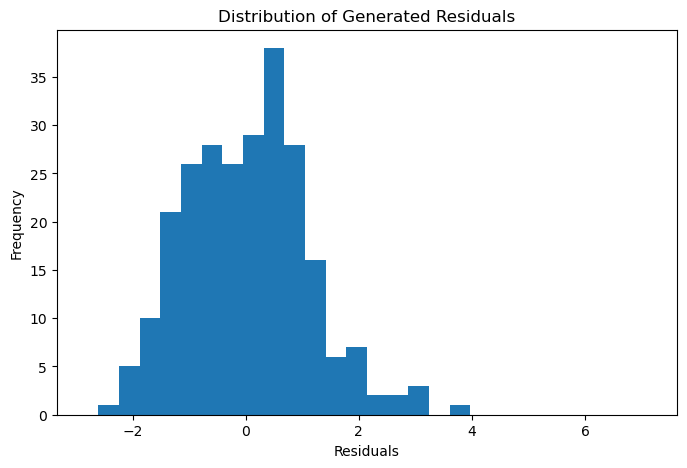

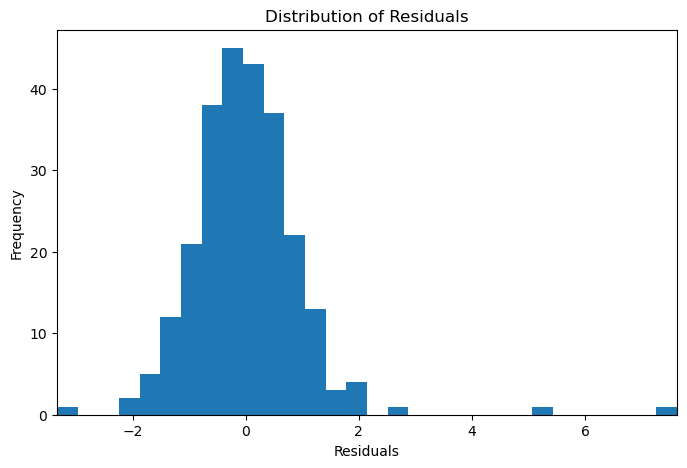

Generated Residuals
Mean: 0.03130417
Variance: 1.1639946
Real Residuals
Mean: 0.015667845033268648
Variance: 0.995983935742972


In [13]:
netG.eval()
with torch.no_grad():
    test_noise = torch.randn(249, p)
    test_rp = torch.ones(249, 1)
    gen_scaled = netG(test_noise, test_rp).numpy()

final_Z_t = scaler.inverse_transform(gen_scaled)

fig_size = (8, 5)

# Common x-axis limits
x_min = min(final_Z_t.min(), df1["Z_t"].min())
x_max = max(final_Z_t.max(), df1["Z_t"].max())

# Common bin edges
bins = np.linspace(x_min, x_max, 31)

# Generated residuals
plt.figure(figsize=fig_size)
plt.hist(final_Z_t.flatten(), bins=bins)
plt.xlim(x_min, x_max)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Generated Residuals")
plt.show()

# Real residuals
plt.figure(figsize=fig_size)
plt.hist(df1["Z_t"], bins=bins)
plt.xlim(x_min, x_max)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

gen = final_Z_t.flatten()

gen_mean = np.mean(gen)
gen_var = np.var(gen)  # population variance

print("Generated Residuals")
print("Mean:", gen_mean)
print("Variance:", gen_var)

real = df1["Z_t"].values
real_mean = np.mean(real)
real_var = np.var(real)  # population variance

print("Real Residuals")
print("Mean:", real_mean)
print("Variance:", real_var)

# Benchmark Against Pure Monte Carlo


Testing based on a hypothetical European call with the underlying Nvidia stock, initiated on May 7 2024 with 60 days to maturity, risk-free rate of 0.05, strike price 90, and assuming 250 trading days. A pure Monte Carlo strategy prices it at about $10.14. The true price of this call using the actual out-of-sample price of the stock is $107.27 on August 2 2024 and thus the true price is $17.27. The hybrid GAN-MC must outperform the pure Monte Carlo by achieiving a price that is closer to $17.27 than pure MC's $10.14.

HG-MC Call Price: 13.744247630093287
Pure Monte Carlo Call Price: 9.46904562689575
True Discounted Payoff: 17.063998481125537


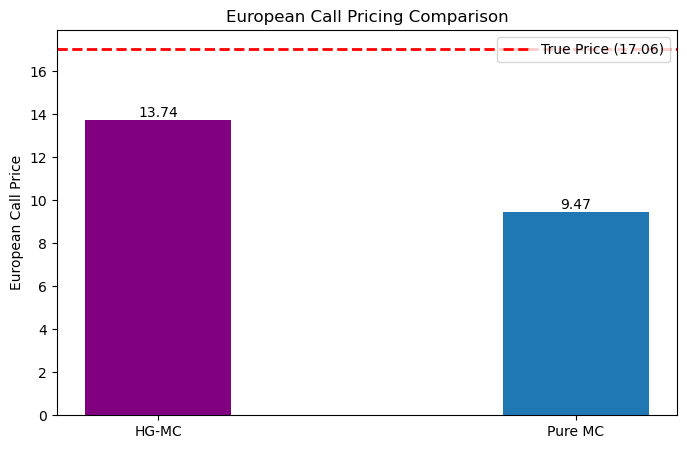

In [11]:
# Initial Parameters

S0 = df1["Close/Last"].iloc[-1]
K = 90
r = 0.05

returns = df1["returns"].dropna()
mean_return = returns.mean()
std_return = returns.std()

# Time assumptions
T = 60 / 250
dt = 1 / 250

# Annualized volatility
sigma = std_return * np.sqrt(250)

# Monte Carlo parameters
n_simulations = 1000
n_steps = 60


# ==========================================================
# HG-MC Pricing
# ==========================================================


# Generate GAN Shocks
netG.eval()

with torch.no_grad():

    # Generate latent noise
    test_noise = torch.randn(n_simulations * n_steps, p)

    # rp input
    test_rp = torch.ones(n_simulations * n_steps, 1)

    # GAN output (scaled)
    gen_scaled = netG(test_noise, test_rp).numpy()

# Undo StandardScaler transformation
final_Z_t = scaler.inverse_transform(gen_scaled)

# Reshape into MC paths
Z_gan = final_Z_t.reshape(n_simulations, n_steps)

# Initialize Price Paths
price_paths = np.zeros((n_simulations, n_steps + 1))

price_paths[:, 0] = S0

# Simulate GBM with GAN shocks
for t in range(1, n_steps + 1):

    price_paths[:, t] = (
        price_paths[:, t - 1]
        * np.exp(
            (r - 0.5 * sigma**2) * dt
            + sigma * np.sqrt(dt) * Z_gan[:, t - 1]
        )
    )


# Terminal prices
ST = price_paths[:, -1]

# European call payoff
payoffs = np.maximum(ST - K, 0)

# Discounted expected payoff
call_price = np.exp(-r * T) * np.mean(payoffs)

print("HG-MC Call Price:", call_price)


# ==========================================================
# Pure Monte Carlo (Standard Gaussian Shocks)
# ==========================================================


# Generate Gaussian shocks
Z_mc = np.random.normal(0, 1, size=(n_simulations, n_steps))

# Initialize paths
price_paths_mc = np.zeros((n_simulations, n_steps + 1))
price_paths_mc[:, 0] = S0

# Simulate GBM
for t in range(1, n_steps + 1):

    price_paths_mc[:, t] = (
        price_paths_mc[:, t - 1]
        * np.exp(
            (r - 0.5 * sigma**2) * dt
            + sigma * np.sqrt(dt) * Z_mc[:, t - 1]
        )
    )

# Terminal prices
ST_mc = price_paths_mc[:, -1]

# Call payoff
payoffs_mc = np.maximum(ST_mc - K, 0)

# Discount back
call_price_mc = np.exp(-r * T) * np.mean(payoffs_mc)

print("Pure Monte Carlo Call Price:", call_price_mc)  


# ==========================================================
# True realized option value
# ==========================================================

terminal_stock_price = 107.27

true_price = np.exp(-r * T) * max(terminal_stock_price - K, 0)

print("True Discounted Payoff:", true_price)


# ==========================================================
# Price Comparison
# ==========================================================

plt.figure(figsize=(8, 5))

prices = [call_price, call_price_mc]
labels = ["HG-MC", "Pure MC"]

bars = plt.bar(
    labels,
    prices,
    width=0.35,
    color=["purple", "tab:blue"]
)

# Numerical labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

# True price line
plt.axhline(
    y=true_price,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"True Price ({true_price:.2f})"
)

plt.ylabel("European Call Price")
plt.title("European Call Pricing Comparison")

plt.legend(loc="upper right")

plt.show()

# Path Price Plots

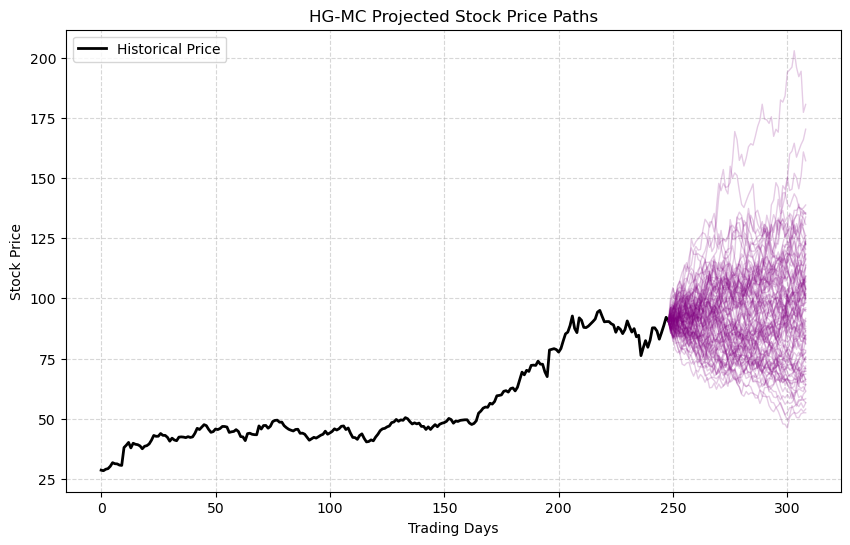

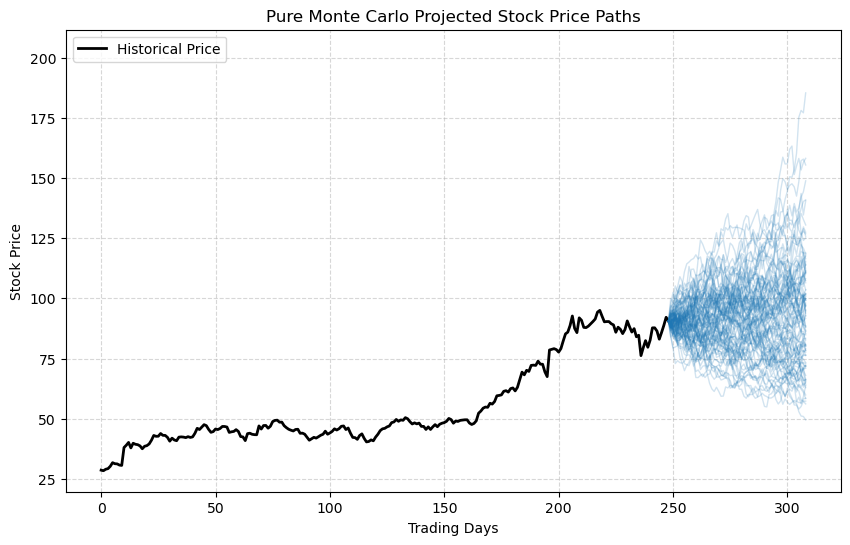

In [12]:
# Historical prices
historical_prices = df1["Close/Last"].values
historical_time = np.arange(len(historical_prices))

# Future time axis (starts at the last historical observation)
future_time = np.arange(
    len(historical_prices) - 1,
    len(historical_prices) + n_steps
)

# Number of simulated paths to display
n_plot = 100

# Compute common y-axis limits using ONLY the displayed paths
y_min = min(
    historical_prices.min(),
    price_paths[:n_plot].min(),
    price_paths_mc[:n_plot].min()
)

y_max = max(
    historical_prices.max(),
    price_paths[:n_plot].max(),
    price_paths_mc[:n_plot].max()
)

# Add a small amount of padding so paths don't touch the border
padding = 0.05 * (y_max - y_min)
y_min -= padding
y_max += padding


# ==========================================================
# HG-MC Projected Price Paths
# ==========================================================

plt.figure(figsize=(10, 6))

# Historical prices
plt.plot(
    historical_time,
    historical_prices,
    color="black",
    linewidth=2,
    label="Historical Price"
)

# HG-MC simulated paths
for i in range(n_plot):
    plt.plot(
        future_time,
        price_paths[i],
        color="purple",
        alpha=0.20,
        linewidth=1
    )

plt.xlabel("Trading Days")
plt.ylabel("Stock Price")
plt.title("HG-MC Projected Stock Price Paths")

plt.ylim(y_min, y_max)

plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


# ==========================================================
# Pure MC Projected Price Paths
# ==========================================================

plt.figure(figsize=(10, 6))

# Historical prices
plt.plot(
    historical_time,
    historical_prices,
    color="black",
    linewidth=2,
    label="Historical Price"
)

# Pure Monte Carlo simulated paths
for i in range(n_plot):
    plt.plot(
        future_time,
        price_paths_mc[i],
        color="tab:blue",
        alpha=0.20,
        linewidth=1
    )

plt.xlabel("Trading Days")
plt.ylabel("Stock Price")
plt.title("Pure Monte Carlo Projected Stock Price Paths")

plt.ylim(y_min, y_max)

plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()